# Data preprocessing Analysis
This notebook compares the original and preprocessed datasets for emotion classification.

### Dataset Rebalancing

To improve dataset quality and class imbalance, labels with very low support were removed. The remaining dataset was rebalanced by undersampling the majority classes, reducing the dominance of highly frequent emotions while increasing the relative representation of minority samples.

## Load Libraries

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns

REPO_ROOT = Path().resolve().parent

## Load Original and Preprocessed Datasets

In [2]:
orig_path = REPO_ROOT / "data" / "train.csv"
df_orig = pd.read_csv(orig_path)

aug_path = REPO_ROOT / "data" / "train_preprocessed.csv"
df_aug = pd.read_csv(aug_path)

print(f"Original dataset shape: {df_orig.shape}")
print(f"Preprocessed dataset shape: {df_aug.shape}")
print(f"Samples removed: {len(df_orig) - len(df_aug)}")
print(f"Retention: {len(df_aug) / len(df_orig):.1%}")

Original dataset shape: (1044, 15)
Preprocessed dataset shape: (444, 15)
Samples removed: 600
Retention: 42.5%


## Compare Label Distributions

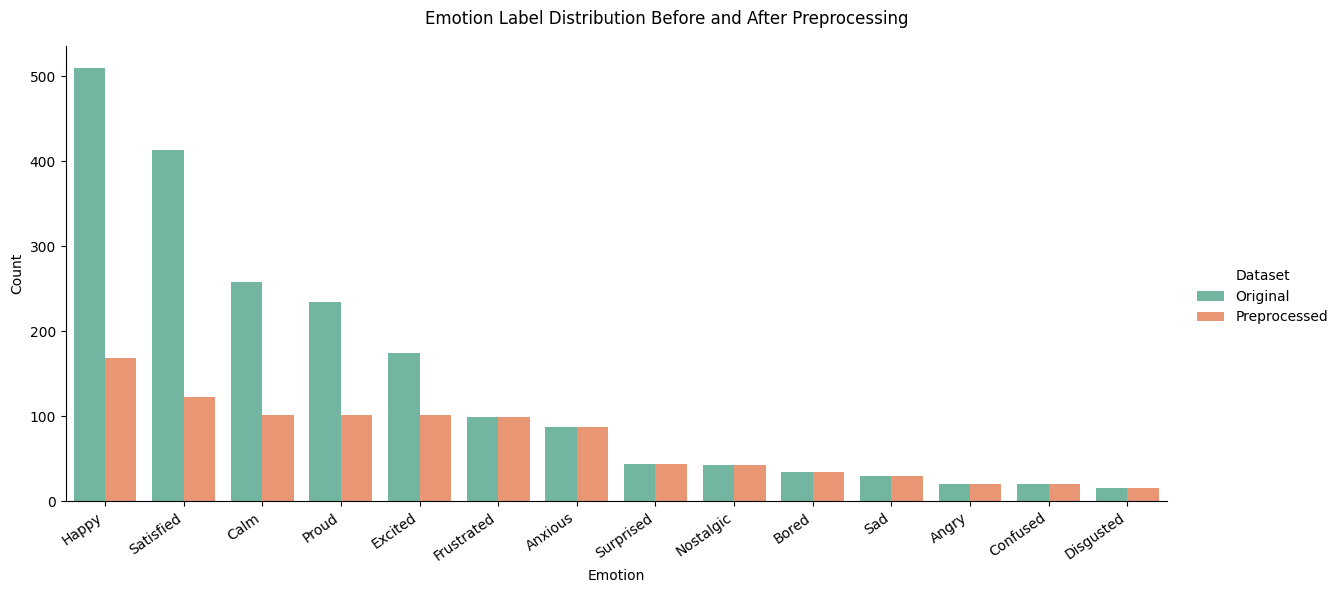

In [3]:
# Extract emotion columns
emotion_cols = [col for col in df_orig.columns if col.startswith("Answer.f1.")]
label_map = {
    col: col.replace("Answer.f1.", "").replace(".raw", "").capitalize()
    for col in emotion_cols
}

# Count label occurrences in both datasets
orig_counts = df_orig[emotion_cols].astype(int).sum().sort_values(ascending=False)
aug_counts = df_aug[emotion_cols].astype(int).sum().sort_values(ascending=False)

# Prepare data in long format for seaborn
bar_df = pd.DataFrame(
    {
        "Label": list(orig_counts.index) * 2,
        "Count": list(orig_counts.values) + list(aug_counts.values),
        "Dataset": ["Original"] * len(orig_counts) + ["Preprocessed"] * len(aug_counts),
    }
)
bar_df["Label"] = bar_df["Label"].map(label_map)

g = sns.catplot(
    data=bar_df,
    x="Label",
    y="Count",
    hue="Dataset",
    kind="bar",
    palette="Set2",
    height=6,
    aspect=2.0,
)
g.set_xticklabels(rotation=35, ha="right")
g.set_axis_labels("Emotion", "Count")
g.figure.suptitle("Emotion Label Distribution Before and After Preprocessing")
g._legend.set_title("Dataset")
g.tight_layout()

## Label Proportion Comparison
Compare the proportion of each label in both datasets.

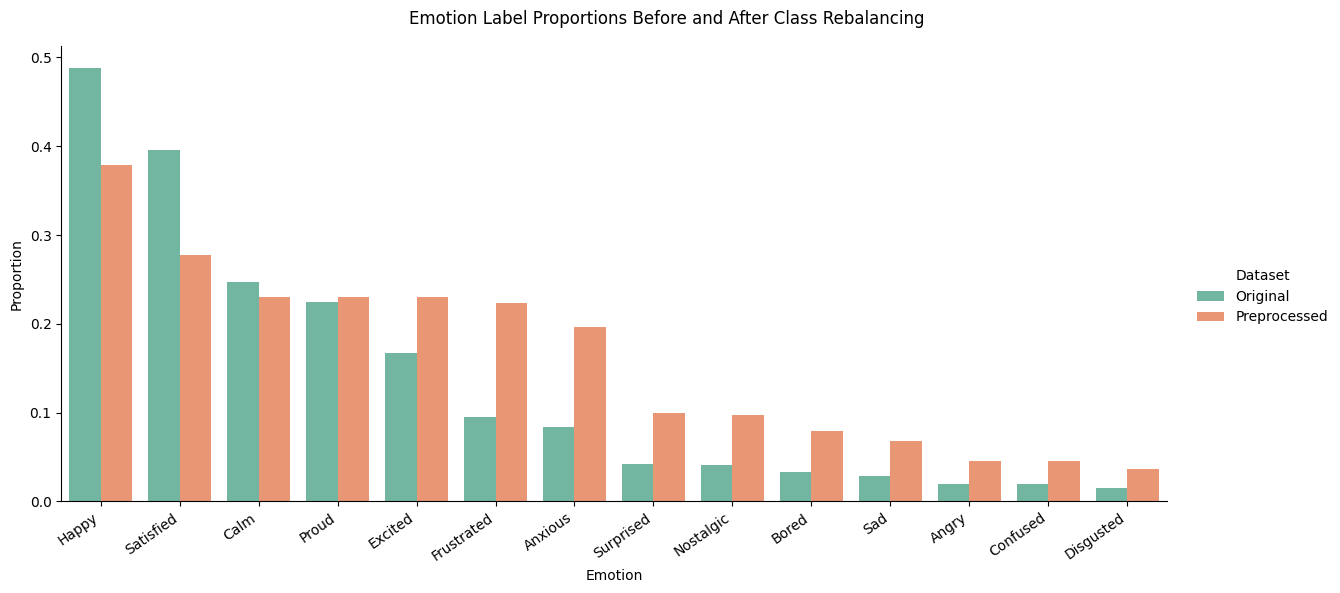

In [5]:
label_order = [label_map[label] for label in orig_counts.index]

orig_props = orig_counts / len(df_orig)
aug_props = aug_counts / len(df_aug)

prop_df = pd.DataFrame({"Original": orig_props, "Preprocessed": aug_props})
prop_df = prop_df.reset_index().melt(id_vars="index", var_name="Dataset", value_name="Proportion")
prop_df = prop_df.rename(columns={"index": "Label"})
prop_df["Label"] = prop_df["Label"].map(label_map)

g = sns.catplot(
    data=prop_df,
    x="Label",
    y="Proportion",
    hue="Dataset",
    kind="bar",
    palette="Set2",
    height=6,
    aspect=2.0,
    order=label_order,
)
g.set_xticklabels(rotation=35, ha="right")
g.set_axis_labels("Emotion", "Proportion")
g.figure.suptitle("Emotion Label Proportions Before and After Class Rebalancing")
g.tight_layout()

### Summary

The preprocessing successfully reduced the dominance of the majority labels (*Happy* and *Satisfied*) while preserving the minority labels. Consequently, the label distribution became substantially more balanced, reducing the imbalance ratio from approximately 31:1 to 10:1. This yielded a more balanced training dataset for learning a multi-label emotion classification model using SetFit.